# AnnData/scverse bridge

This scenario shows the AnnNet/AnnData boundary on a tiny graph.


In [1]:
import annnet as an

an.info()


Version,v0.2.0
License,BSD-3-Clause
Authors,"Youssef Zerta ✉, Daniele Bottazzi ✉, Denes Turei ✉"
Repository,https://github.com/saezlab/annnet
Documentation,https://saezlab.github.io/annnet/reference/
Default graph backend,networkx
Default plot backend,graphviz
Graph backends,✓networkx✓igraph✗graph-tool✓pyg
Plot backends,✓graphviz✗pydot✓matplotlib
Tabular data backends,✓polars✓pandas✓pyarrow
I/O modules,✓annnet✓json/ndjson✓dataframes✓csv✓excel✓graphml/gexf✓sif✓cx2✓parquet✓zarr✗sbml✓scverse✓omnipath


## Build an annotated graph


In [2]:
G = an.AnnNet(directed=True)
G.add_vertices('cell_A', kind='cell', score=1.0, cluster=0)
G.add_vertices('cell_B', kind='cell', score=2.0, cluster=1)
G.add_vertices('cell_C', kind='cell', score=1.6, cluster=1)
G.add_edges('cell_A', 'cell_B', edge_id='transition_ab', weight=0.6)
G.add_edges('cell_A', 'cell_B', edge_id='velocity_ab', weight=0.35)
G.add_edges('cell_B', 'cell_C', edge_id='transition_bc', weight=0.9)
G.add_edges('cell_B', 'cell_C', edge_id='neighborhood_bc', directed=False, weight=0.5)
G.attrs.set_edge_attrs('transition_ab', relation='state_transition')
G.attrs.set_edge_attrs('velocity_ab', relation='rna_velocity')

G.views.vertices()


vertex_id,kind,score,cluster
str,str,f64,i64
"""cell_A""","""cell""",1.0,0
"""cell_B""","""cell""",2.0,1
"""cell_C""","""cell""",1.6,1


## Draw the graph before conversion


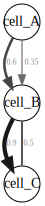

In [3]:
from annnet.utils import plotting

plotting.plot(G, backend='graphviz', show_edge_labels=True)


## Convert to AnnData and inspect the tables


In [4]:
from annnet.experimental.scverse import to_anndata, from_anndata

adata = to_anndata(G)
restored = from_anndata(adata)

print('AnnData shape:', adata.shape)
print('uns keys:', sorted(adata.uns))
print('round-trip shape:', restored.shape)
display(adata.obs)
display(adata.var)


AnnData shape: (3, 4)
uns keys: ['__annnet__']
round-trip shape: (3, 4)


,kind,score,cluster,annnet_vertex_id
obs_id,,,,
cell_A,cell,1.0,0,cell_A
cell_B,cell,2.0,1,cell_B
cell_C,cell,1.6,1,cell_C


,weight,directed,edge_type,multilayer_kind,edge_layers,source,target,relation
edge_id,,,,,,,,
transition_ab,0.60,True,binary,intra,None,cell_A,cell_B,state_transition
velocity_ab,0.35,True,binary,intra,None,cell_A,cell_B,rna_velocity
transition_bc,0.90,True,binary,intra,None,cell_B,cell_C,NaN
neighborhood_bc,0.50,False,binary,intra,None,cell_B,cell_C,NaN


AnnNet maps graph vertices to `obs`, structural edges to `var`,
and incidence to `X`. AnnNet-specific structure is preserved
in `uns`, so the round trip can recover parallel and undirected
graph structure.
